# Load groundwork 

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


import scanpy as sc

import os

import scvi

import seaborn as sns

%matplotlib inline

def order_m(m):
    n = min(*m.shape)
    
    ordered_cols = []
    remain_cols = list(range(m.shape[1]))
    
    for i in range(n):
        ic = m[i, remain_cols].argmax()
        c = remain_cols[ic]
        ordered_cols.append(c)
        remain_cols.remove(c)
    
    return ordered_cols, remain_cols



canonical_markers = ["IL32", "LTB", "CD3D",
    "IL7R", "LDHB", "FCGR3A", 
    "CD68", "MS4A1", "GNLY", 
    "CD3E", "CD14", "CD14", 
    "FCGR3A", "LYZ", "PPBP", 
    "CD8A", "PPBP", "CST3", 
    "NKG7", "MS4A7", "MS4A1", 
    "CD8A", "CD4", "NCAM1"]

    

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing CSCDataset from `anndata.experimental` is deprecated. Import anndata.abc.CSCDataset instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndat

In [2]:
## Entropy filtered atac
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'
entropy_downstream_dir = os.path.join(entropy_dir, 'DownstreamReanalysis')
entropy_peak_file = os.path.join(entropy_downstream_dir, 'entropy_peakvi.h5ad')
peak_file = os.path.join(entropy_downstream_dir, 'standard_peakvi.h5ad')

entropy_peak = sc.read_h5ad(entropy_peak_file)
peak = sc.read_h5ad(peak_file)

# Rename peakvi clustering columns
entropy_peak.obs['clusters_peakvi_entropy'] = entropy_peak.obs['clusters_peakvi']
peak.obs['clusters_peakvi_standard'] = peak.obs['clusters_peakvi']

# Load entropy score and add to entropy_peak obs
entropy_score_file = os.path.join(entropy_dir, 'entropy_filtered_bc_df.tsv')
entropy_score_pd = pd.read_csv(entropy_score_file, sep=',', index_col=0)
entropy_peak.obs = entropy_peak.obs.merge(entropy_score_pd[['Entropy', 'Entropy_open_region']], left_on='barcodes', right_index=True, how='left')

# atac clsutering at higher resolutions (than previously used)
atac_resolution = 0.5
sc.tl.leiden(entropy_peak, key_added='clusters_peakvi_highres_entropy', resolution=atac_resolution)
sc.tl.leiden(peak, key_added='clusters_peakvi_highres_standard', resolution=atac_resolution)


# atac-rna-barcode map 
bc_map_file = '/home/syyang/adipose_ln/multiom/atac_rna_barcodes_map.tsv'
bc_map_pd = pd.read_csv(bc_map_file, sep='\t')


# Load rna h5 
RNA_info_dir = os.path.join(entropy_dir, 'RNA_info')
h5_rna_ = sc.read_h5ad(os.path.join(RNA_info_dir, 'allbc_rna.h5ad'))



## load peakvi models for DARS analysis 
standard_peak_model_dir = os.path.join(entropy_downstream_dir, 'standard_peak_peakvi_model')
entropy_peak_model_dir =os.path.join(entropy_downstream_dir, 'entropy_peak_peakvi_model')
standard_peak_model =scvi.model.PEAKVI.load(standard_peak_model_dir, adata=peak)
entropy_peak_model =scvi.model.PEAKVI.load(entropy_peak_model_dir, adata=entropy_peak)


# Summary statistics about Fraction of Reads in Peaks (FRIP)
Union_cell_df = pd.read_csv(os.path.join(entropy_dir, '_cell_palling_comparison',  'Union_3set_atac_BCs.tsv'), sep='\t')

/tmp/ipykernel_625352/967887826.py:21: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(entropy_peak, key_added='clusters_peakvi_highres_entropy', resolution=atac_resolution)


INFO     File                                                                                                      
         /mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F/DownstreamReanalysis/standard_peak_peakvi_mode
         l/model.pt already downloaded                                                                             
INFO     File                                                                                                      
         /mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F/DownstreamReanalysis/entropy_peak_peakvi_model
         /model.pt already downloaded                                                                              


/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/scvi/model/base/_save_load.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(model_

In [4]:
entropy_peak, peak, h5_rna_, bc_map_pd.shape, Union_cell_df.columns, 

(AnnData object with n_obs × n_vars = 2126 × 36729
     obs: 'barcodes', '_scvi_batch', '_scvi_labels', 'clusters_peakvi', 'clusters_peakvi_entropy', 'Entropy', 'Entropy_open_region', 'clusters_peakvi_highres_entropy'
     var: 'peak'
     uns: '_scvi_manager_uuid', '_scvi_uuid', 'clusters_peakvi', 'neighbors', 'umap', 'clusters_peakvi_highres_entropy'
     obsm: 'X_peakvi', 'X_umap'
     obsp: 'connectivities', 'distances',
 AnnData object with n_obs × n_vars = 2126 × 31116
     obs: 'barcodes', '_scvi_batch', '_scvi_labels', 'clusters_peakvi', 'clusters_peakvi_standard', 'clusters_peakvi_highres_standard'
     var: 'peak'
     uns: '_scvi_manager_uuid', '_scvi_uuid', 'clusters_peakvi', 'neighbors', 'umap', 'clusters_peakvi_highres_standard'
     obsm: 'X_peakvi', 'X_umap'
     obsp: 'connectivities', 'distances',
 AnnData object with n_obs × n_vars = 687495 × 36601
     obs: 'barcodes', 'rna_barcodes', 'atac_barcodes', 'total_RNA_UMI', 'total_RNA_UMI_log', 'n_genes_by_RNA_counts', 'N

# Plot atac re-clustering with higher resolution

## Matching atac bc with RNA bc

In [5]:
bc_map = bc_map_pd.set_index('atac_barcodes')

entropy_peak.obs['atac_bc'] =  entropy_peak.obs['barcodes'].map(lambda x: x.split('-1')[0])
entropy_peak.obs.set_index('atac_bc', inplace=True)
if 'rna_barcodes' not in entropy_peak.obs.columns:
    entropy_peak.obs = entropy_peak.obs.join(bc_map, how='inner')


peak.obs['atac_bc'] =  peak.obs['barcodes'].map(lambda x: x.split('-1')[0])
peak.obs.set_index('atac_bc', inplace=True)
if 'rna_barcodes' not in peak.obs.columns:
    peak.obs = peak.obs.join(bc_map, how='inner')


bc_passed_entropy_df = entropy_peak.obs[['rna_barcodes']]

# RNA clustering

In [17]:
# select only the barcodes that passed entropy filtering
h5_rna = h5_rna_[h5_rna_.obs['rna_barcodes'].isin(bc_passed_entropy_df['rna_barcodes']), :].copy()
h5_rna.obs.set_index('rna_barcodes', inplace=True)


In [18]:
h5_rna, h5_rna_.shape

(AnnData object with n_obs × n_vars = 2126 × 36601
     obs: 'barcodes', 'atac_barcodes', 'total_RNA_UMI', 'total_RNA_UMI_log', 'n_genes_by_RNA_counts', 'N_MT_counts', 'MT%'
     var: 'feature_id', 'name', 'feature_type', 'chrom', 'start', 'end', 'gene_name',
 (687495, 36601))

In [19]:
sc.pp.filter_genes(h5_rna, min_counts=3)
h5_rna.raw = h5_rna # keep full dimension safe
h5_rna.layers['counts'] = h5_rna.X
sc.pp.highly_variable_genes(
h5_rna,
flavor="seurat_v3",
n_top_genes=4000,
layer="counts",
subset=False)

In [20]:
vae_model_folder=os.path.join(entropy_dir, "_RNA_scvi_model")


# scvi.settings.seed = 0
# scvi.model.SCVI.setup_anndata(h5_rna, layer="counts")
# vae = scvi.model.SCVI(h5_rna, n_layers=3, n_latent=30, gene_likelihood="nb")
# vae.train()
# h5_rna.obsm["RNA_scVI"] = vae.get_latent_representation()

# sc.pp.neighbors(h5_rna, use_rep='RNA_scVI')
# sc.tl.umap(h5_rna, min_dist=0.3)

# print("Save integrated samples into .h5ad file and trained SCVI model into subfolder\n") 
# vae.save(vae_model_folder)
vae =scvi.model.SCVI.load(vae_model_folder, adata=h5_rna)
h5_rna.obsm["RNA_scVI"] = vae.get_latent_representation()
sc.pp.neighbors(h5_rna, use_rep='RNA_scVI')
sc.tl.umap(h5_rna, min_dist=0.3)


INFO     File /mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F/_RNA_scvi_model/model.pt already         
         downloaded                                                                                                


/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/scvi/model/base/_save_load.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(model_

In [21]:
# clustering using scVI latent representation via Leiden
sc.tl.leiden(h5_rna, key_added="leiden_RNA_scVI", resolution=atac_resolution + 0.1)

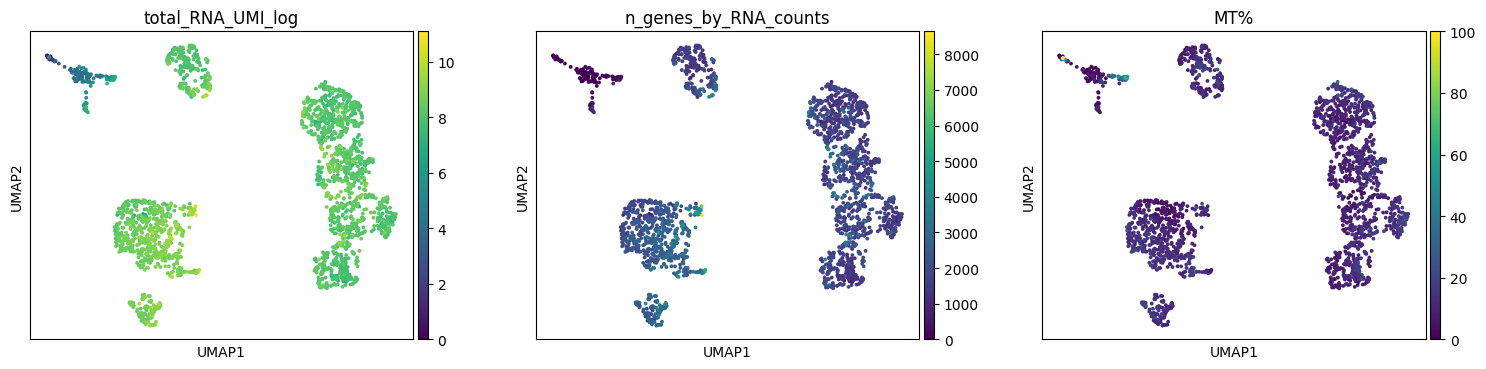

In [22]:
with plt.rc_context({'figure.figsize': (5, 4)}):
    sc.pl.umap(h5_rna, color=['total_RNA_UMI_log', 'n_genes_by_RNA_counts', 'MT%'], wspace=0.2, size=30, ncols=3)

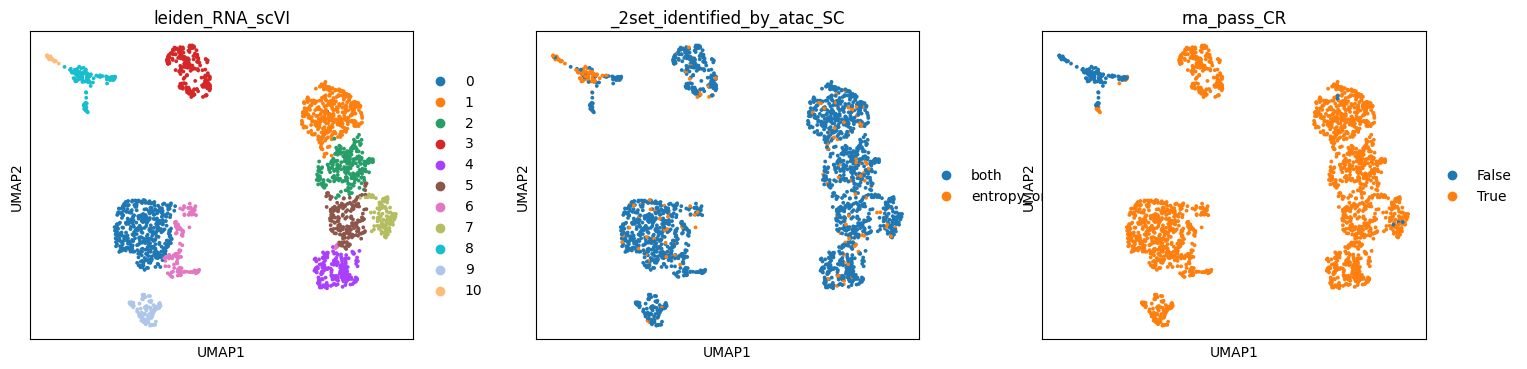

In [23]:
if '_2set_identified_by_atac_SC' not in h5_rna.obs.columns:
    h5_rna.obs = h5_rna.obs.merge(Union_cell_df[['_2set_identified_by_atac_SC', 'rna_barcodes']].set_index('rna_barcodes'), left_index=True, right_index=True, how='left')

if 'rna_pass_CR' not in h5_rna.obs.columns:
    h5_rna.obs = h5_rna.obs.merge(Union_cell_df[['rna_pass_CR', 'rna_barcodes']].set_index('rna_barcodes'), left_index=True, right_index=True, how='left')
    

with plt.rc_context({'figure.figsize': (5, 4)}):
    sc.pl.umap(h5_rna, color=['leiden_RNA_scVI', '_2set_identified_by_atac_SC', 'rna_pass_CR'], wspace=0.2, size=30, ncols=3)

In [24]:
Union_cell_df[['rna_pass_CR', 'rna_barcodes']].set_index('rna_barcodes').groupby('rna_pass_CR').size()

rna_pass_CR
False     341
True     2046
dtype: int64

In [26]:
col_list = ['rna_barcodes',  'total_fragments',
        'rna_pass_CR', 'frag_overlap_CR_1stRound_peaks', 
        'frag_overlap_entropy_filtered_peaks',
        'Entropy', '_2set_identified_by_atac_SC',]

for col in col_list:
    if col in h5_rna.obs.columns:
        col_list.remove(col)
        
if len(col_list) > 1:
    h5_rna.obs = h5_rna.obs.merge(Union_cell_df[col_list].set_index('rna_barcodes'), left_index=True, right_index=True, how='left')

h5_rna.obs['Raw_peak_FRIP'] = h5_rna.obs['frag_overlap_CR_1stRound_peaks'] / h5_rna.obs['total_fragments'] * 100 
h5_rna.obs['Entropy_peak_FRIP'] = h5_rna.obs['frag_overlap_entropy_filtered_peaks'] / h5_rna.obs['total_fragments'] * 100


In [ ]:
_col_list = ['atac_bc',  'total_fragments',
        'rna_pass_CR', 'frag_overlap_CR_1stRound_peaks', 
        'frag_overlap_entropy_filtered_peaks',
        'Entropy', '_2set_identified_by_atac_SC',]

col_list = _col_list.copy()

for col in col_list:
    if col in entropy_peak.obs.columns:
        col_list.remove(col)
        
if len(col_list) > 1:
    entropy_peak.obs = entropy_peak.obs.merge(Union_cell_df[col_list].set_index('rna_barcodes'), left_index=True, right_index=True, how='left')

In [ ]:
col_list = _col_list.copy()

for col in col_list:
    if col in entropy_peak.obs.columns:
        col_list.remove(col)
        
if len(col_list) > 1:
    entropy_peak.obs = entropy_peak.obs.merge(Union_cell_df[col_list].set_index('atac_bc'), left_index=True, right_index=True, how='left')

In [ ]:
col_list = _col_list.copy()

for col in col_list:
    if col in peak.obs.columns:
        col_list.remove(col)
        
if len(col_list) > 1:
    peak.obs = peak.obs.merge(Union_cell_df[col_list].set_index('atac_bc'), left_index=True, right_index=True, how='left')

In [27]:
# See concordance between two clustering results between Standard peak clustering and Entropy filtered peak clustering
entropy_peak_df = entropy_peak.obs.copy()
entropy_peak_df.set_index('barcodes', inplace=True)

peak_df = peak.obs.copy()
peak_df.set_index('barcodes', inplace=True)

## Marker genes

In [ ]:

canonical_markers_avail = [g for g in canonical_markers if g in h5_rna.var['gene_name'].values ]


# with plt.rc_context({'figure.figsize': (5, 5)}):
sc.pl.umap(h5_rna, color=canonical_markers_avail, wspace=0.1, ncols=4, size=40, gene_symbols='gene_name', layer='log1p_counts')

In [ ]:
sc.pl.umap(h5_rna, color=['SELL', 'IL7R', 'ITGAM'], size=40 , gene_symbols='gene_name', layer='log1p_counts')
# CD127 protein : gene IL7R (T cells subtype)
# CD62L protein : gene SELL (T cells subtype)
# CD11B protein: ITGAM gene: T cells do not express ITGAM (myloid)

In [ ]:
sc.pl.umap(h5_rna, color=['CD3D', 'IL7R', 'CD8A', 'CD8B',  'NKG7', 'GNLY', 'FGFBP2', 'FCGR3A', 'FCER1G'], size=40 , gene_symbols='gene_name', layer='log1p_counts')

In [ ]:
sc.pl.umap(h5_rna, color=[ 'ITGAX',   'CD14','FCGR3A' ], size=40 , gene_symbols='gene_name', layer='log1p_counts')
# CD11c protein: gene ITGAX -- DC 
# CD16 protein: gene FCGR3A -- NC monocytes

#### gamma-delta T cells 

In [ ]:
sc.pl.umap(h5_rna, color=[ 'TRDC',   'TRGC1','TRDV2', 'TRGV9'], size=40 , ncols=2, gene_symbols='gene_name', layer='log1p_counts') #

### pDCs and C14+ monocytes

In [ ]:
sc.pl.umap(h5_rna, color=[ 'CD14', 'IRF7', 'TLR9', 'TCF4', 'CLEC4C' ], size=40 ,ncols=3 ,gene_symbols='gene_name', layer='log1p_counts') #

####  MAIT/NK-T cells 

In [ ]:
sc.pl.umap(h5_rna, color=[ 'KLRG1',   'NCR3','KLRB1'], size=40 ,gene_symbols='gene_name', layer='log1p_counts') #

#### 

In [ ]:
sc.pl.umap(h5_rna, color=[ 'NCAM1',   'TBX21','IFNG', 'NKG7', 'XCL2', 'NCR1' ], size=40 ,ncols=3 ,gene_symbols='gene_name', layer='log1p_counts') #

#### Mono 

In [ ]:
sc.pl.umap(h5_rna, color=[ 'CD14',   'HLA-DRA', 'TNF', 'IL1B' ], size=40 ,ncols=3 ,gene_symbols='gene_name', layer='log1p_counts') #

In [ ]:
# cell-type idendification by Juliana

cluster_average_df = pd.DataFrame(index=h5_rna.var['gene_name'])

for c in h5_rna.obs['leiden_RNA_scVI'].unique():
    a = h5_rna[h5_rna.obs['leiden_RNA_scVI'] == c, :].layers['log1p_counts'].mean(axis=0)
    cluster_average_df[c] = np.asarray(a).flatten()
    
cluster_average_df.to_csv('HiJuliana_check_pbmc_rna_cluster_average_normalized_expression.csv')

cluster_average_df.head()

## Cell-type annotation from Julianaa

### Provicve clsuter to cell-type map

In [ ]:
# # Juliana's cell type annotation in the previous analysis (_missing1cell_DownstreamReanalysis subdir )
# RNAcluster_celltype_map = {
# '0': 'CD14+ Mo',
# '1': 'CD4+CD8+ naive T cells',
# '2': 'Tregs',
# '3': 'B cells',
# '4': 'ILC/NK cells',
# '5': 'MAIT/NK T cells',
# '6': 'gammaSignma T cells',
# '7': 'Unknown',
# '8': 'CD16+Mo',
# '9': 'pDCs',
# '10': 'Plasma cells (noisy)'
# }
# h5_rna.obs['celltype'] = h5_rna.obs['leiden_RNA_scVI'].map(RNAcluster_celltype_map)

# ## do NOT !!! delete 
# ## do NOT !!! delete 
# ## do NOT !!! delete 


# # ## Save each cell-type's barcode 
# # rna_cell_type_subdir = os.path.join(entropy_dir,  '_rna_cell_types')
# # os.makedirs(rna_cell_type_subdir, exist_ok=True)

# # for cluster in h5_rna.obs['leiden_RNA_scVI'].unique():
# #     write_file = 'RNAcluster_' + str(cluster) + '_df.csv' 
# #     write_file_path = os.path.join(rna_cell_type_subdir, write_file)
# #     h5_rna.obs.loc[h5_rna.obs['leiden_RNA_scVI'] == cluster, :].to_csv(write_file_path, index=False)    
# # # write cell-type mapping file
# # celltype_map_file = os.path.join(rna_cell_type_subdir, 'RNAcluster_celltype_map.tsv')
# # with open(celltype_map_file, 'w') as f:
# #     for k, v in RNAcluster_celltype_map.items():
# #         f.write(f"{k}\t{v}\n")

previous_h5_rna_file='/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F/_missing1cell_DownstreamReanalysis/_h5_rna/h5_rna.h5'
previous_h5_rna = sc.read_h5ad(previous_h5_rna_file)

In [32]:
a = h5_rna.obs.join(previous_h5_rna.obs[['leiden_RNA_scVI', 'celltype']].rename(columns={'leiden_RNA_scVI': 'leiden_RNA_scVI_previous', 'celltype': 'celltype_previous'}), how='left')
a.head(2)

,barcodes,atac_barcodes,total_RNA_UMI,total_RNA_UMI_log,n_genes_by_RNA_counts,N_MT_counts,MT%,_scvi_batch,_scvi_labels,leiden_RNA_scVI,standard_peak_FRIP,entropy_peak_FRIP,Entropy,Entropy_log,leiden_RNA_scVI_previous,celltype_previous
rna_barcodes,,,,,,,,,,,,,,,,
AAACAGCCAGGCTACT,AAACAGCCAGGCTACT-1,ACAGCGGGTTTGTAGC,3933.0,8.277412,1776,519.0,13.196033,0,0,1,67.551622,69.970501,0.130478,-0.884463,1,CD4+CD8+ naive T cells
AAACATGCAAGGATTA,AAACATGCAAGGATTA-1,CATTTAGGTAACAGCA,3561.0,8.178078,1680,401.0,11.260882,0,0,7,67.955950,70.364401,0.197080,-0.705357,5,MAIT/NK T cells


In [33]:
a.groupby(['leiden_RNA_scVI', 'leiden_RNA_scVI_previous']).size().unstack().fillna(0).astype(int)

/tmp/ipykernel_496479/2247989077.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  a.groupby(['leiden_RNA_scVI', 'leiden_RNA_scVI_previous']).size().unstack().fillna(0).astype(int)


leiden_RNA_scVI_previous,0,1,2,3,4,5,6,7,8,9,10
leiden_RNA_scVI,,,,,,,,,,,
0,425,0,0,8,0,0,0,0,0,0,0
1,0,339,18,0,0,1,0,1,0,0,0
2,0,19,224,0,0,4,3,0,0,0,0
3,0,0,0,210,0,0,0,0,0,0,2
4,0,0,0,0,181,11,2,0,0,0,0
5,0,6,14,0,14,12,136,0,0,0,0
6,55,0,0,2,0,9,0,0,0,59,0
7,0,0,3,0,0,121,1,0,0,0,0
8,0,0,0,0,1,0,0,99,0,0,21


In [34]:
a.groupby(['leiden_RNA_scVI', 'celltype_previous']).size().unstack().fillna(0).astype(int)

/tmp/ipykernel_496479/862623103.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  a.groupby(['leiden_RNA_scVI', 'celltype_previous']).size().unstack().fillna(0).astype(int)


celltype_previous,CD14+ Mo,CD4+CD8+ naive T cells,Tregs,B cells,ILC/NK cells,MAIT/NK T cells,gammaSignma T cells,Unknown,CD16+Mo,pDCs,Plasma cells (noisy)
leiden_RNA_scVI,,,,,,,,,,,
0,425,0,0,8,0,0,0,0,0,0,0
1,0,339,18,0,0,1,0,1,0,0,0
2,0,19,224,0,0,4,3,0,0,0,0
3,0,0,0,210,0,0,0,0,0,0,2
4,0,0,0,0,181,11,2,0,0,0,0
5,0,6,14,0,14,12,136,0,0,0,0
6,55,0,0,2,0,9,0,0,0,59,0
7,0,0,3,0,0,121,1,0,0,0,0
8,0,0,0,0,1,0,0,99,0,0,21


## plot to see cell-type fraction of reads in peaks (FRIP) for standard peak set and entropy peak set

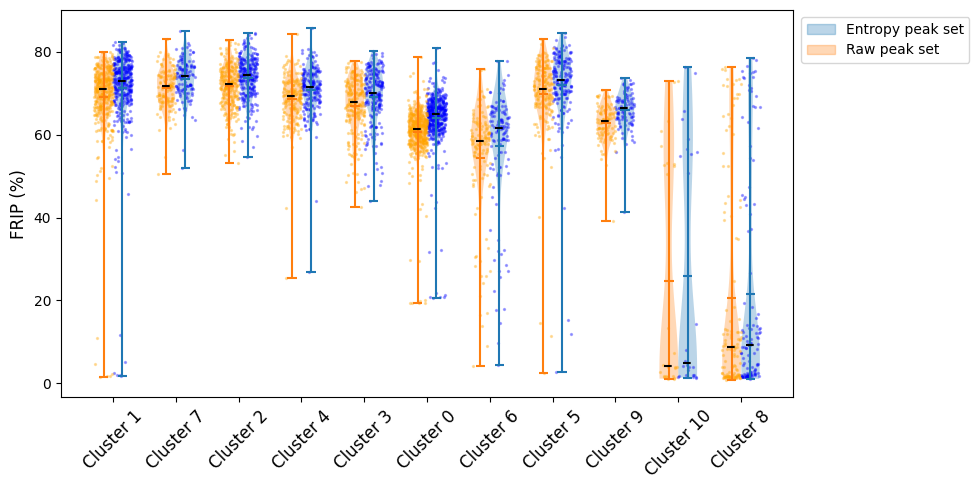

In [29]:
# color_maps = {'0': 'blue', '1': 'orange', '2': 'green', '3': 'red', '4': 'purple',
#               '5': 'brown', '6': 'pink', '7': 'gray', '8': 'olive', '9': 'cyan', '10': 'magenta'}
x_positions = range(11)
widths=0.3
labels = []

def add_label(violin, label):
    color = violin["bodies"][0].get_facecolor().flatten()
    labels.append((mpatches.Patch(color=color), label))
    
fig, ax = plt.subplots( figsize=(10, 5))

# Violin plots
clusters = h5_rna.obs['leiden_RNA_scVI'].unique()
standard_peak_data = [h5_rna.obs.loc[h5_rna.obs['leiden_RNA_scVI'] == c, 'Raw_peak_FRIP'] for c in clusters]
entropy_peak_data = [h5_rna.obs.loc[h5_rna.obs['leiden_RNA_scVI'] == c, 'Entropy_peak_FRIP'] for c in clusters]
v1 = ax.violinplot( entropy_peak_data, 
              positions=[x + 0.5*widths for x in x_positions], widths=widths, vert=True, 
              showmeans=True, showmedians=True)
add_label(v1, 'Entropy peak set',)
v2 = ax.violinplot( standard_peak_data, 
              positions=[x - 0.5*widths for x in x_positions], widths=widths, vert=True, 
              showmeans=True, showmedians=True)
add_label(v2, 'Raw peak set',)


for v in [v1, v2]:
    v['cmedians'].set_color('black')
    v['cmedians'].set_linewidth(1.5)
    v['cmedians'].set_linestyle('--')
    v['cmeans'].set_linewidth(1.5)
# Overlay jittered scatter points
np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width=0.15, color='blue'):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=0.3, s=2) # s controls point size


for i, group_data in enumerate(entropy_peak_data):
    add_jittered_points(ax, group_data, [x + 0.5*widths for x in x_positions][i], color='blue')
for i, group_data in enumerate(standard_peak_data):
    add_jittered_points(ax, group_data, [x - 0.5*widths for x in x_positions][i], color='orange')


ax.set_xticks(x_positions)
# ax.set_xticklabels([RNAcluster_celltype_map[str(c)] for c in x_positions], rotation=45, ha='right', fontsize=12)
ax.set_xticklabels([f'Cluster {clusters[x]}' for x in x_positions], rotation=45, ha='center', fontsize=12)
ax.set_ylabel('FRIP (%)', fontsize=12)
plt.legend(*zip(*labels), loc='upper right', bbox_to_anchor=(1.25, 1), ncol=1)

plt.tight_layout()


# Load fragments to calculate percentage in CTCF regions

In [30]:
Union_cell_subdir=os.path.join(entropy_dir, '_cell_palling_comparison')


cCREs_frag_subdir = os.path.join(Union_cell_subdir, 'cCREs_over_frag')

H3K4me3_CTCF_frag_file=os.path.join(cCREs_frag_subdir, 'fragments_H3K4me3_CTCF.tsv')
CTCF_CTCF_frag_file=os.path.join(cCREs_frag_subdir, 'fragments_CTCF_CTCF.tsv')
pELS_CTCF_frag_file=os.path.join(cCREs_frag_subdir, 'fragments_pELS_CTCF.tsv')
dELS_CTCF_frag_file=os.path.join(cCREs_frag_subdir, 'fragments_dELS_CTCF.tsv')
PLS_CTCF_frag_file=os.path.join(cCREs_frag_subdir, 'fragments_PLS_CTCF.tsv')


H3K4me3_CTCF_frag = pd.read_csv(H3K4me3_CTCF_frag_file, sep='\t', header=None)
CTCF_CTCF_frag = pd.read_csv(CTCF_CTCF_frag_file, sep='\t', header=None)
pELS_CTCF_frag = pd.read_csv(pELS_CTCF_frag_file, sep='\t', header=None)
dELS_CTCF_frag = pd.read_csv(dELS_CTCF_frag_file, sep='\t', header=None)
PLS_CTCF_frag = pd.read_csv(PLS_CTCF_frag_file, sep='\t', header=None)


for df in [H3K4me3_CTCF_frag, CTCF_CTCF_frag, pELS_CTCF_frag, dELS_CTCF_frag, PLS_CTCF_frag]:
    df.columns = ['chrom', 'start', 'end', 'atac_barcodes', 'bp_overlap']
    df['atac_bc'] = df['atac_barcodes'].map(lambda x: x.split('-1')[0])

In [31]:
H3K4me3_CTCF_perbc = H3K4me3_CTCF_frag.groupby('atac_bc').size().to_frame('H3K4me3_CTCF_frag_count')
CTCF_CTCF_perbc = CTCF_CTCF_frag.groupby('atac_bc').size().to_frame('CTCF_CTCF_frag_count')
pELS_CTCF_perbc = pELS_CTCF_frag.groupby('atac_bc').size().to_frame('pELS_CTCF_frag_count')
dELS_CTCF_perbc = dELS_CTCF_frag.groupby('atac_bc').size().to_frame('dELS_CTCF_frag_count')
PLS_CTCF_perbc = PLS_CTCF_frag.groupby('atac_bc').size().to_frame('PLS_CTCF_frag_count')



In [32]:
if 'H3K4me3_CTCF_frag_count' not in h5_rna.obs.columns:
    h5_rna.obs = h5_rna.obs.merge(H3K4me3_CTCF_perbc, left_on='atac_barcodes', right_index=True, how='left')

if 'CTCF_CTCF_frag_count' not in h5_rna.obs.columns:
    h5_rna.obs = h5_rna.obs.merge(CTCF_CTCF_perbc, left_on='atac_barcodes', right_index=True, how='left')

if 'pELS_CTCF_frag_count' not in h5_rna.obs.columns:
    h5_rna.obs = h5_rna.obs.merge(pELS_CTCF_perbc, left_on='atac_barcodes', right_index=True, how='left')

if 'dELS_CTCF_frag_count' not in h5_rna.obs.columns:
    h5_rna.obs = h5_rna.obs.merge(dELS_CTCF_perbc, left_on='atac_barcodes', right_index=True, how='left')

if 'PLS_CTCF_frag_count' not in h5_rna.obs.columns:
    h5_rna.obs = h5_rna.obs.merge(PLS_CTCF_perbc, left_on='atac_barcodes', right_index=True, how='left')

for col in  ['H3K4me3_CTCF_frag_count', 'CTCF_CTCF_frag_count', 'pELS_CTCF_frag_count', 'dELS_CTCF_frag_count', 'PLS_CTCF_frag_count']:
    h5_rna.obs[col].fillna(0, inplace=True)

h5_rna.obs['H3K4me3_CTCF_frag%'] = h5_rna.obs['H3K4me3_CTCF_frag_count'].fillna(0) / h5_rna.obs['total_fragments'] * 100
h5_rna.obs['CTCF_CTCF_frag%'] = h5_rna.obs['CTCF_CTCF_frag_count'].fillna(0) / h5_rna.obs['total_fragments'] * 100
h5_rna.obs['pELS_CTCF_frag%'] = h5_rna.obs['pELS_CTCF_frag_count'].fillna(0) / h5_rna.obs['total_fragments'] * 100
h5_rna.obs['dELS_CTCF_frag%'] = h5_rna.obs['dELS_CTCF_frag_count'].fillna(0) / h5_rna.obs['total_fragments'] * 100
h5_rna.obs['PLS_CTCF_frag%'] = h5_rna.obs['PLS_CTCF_frag_count'].fillna(0) / h5_rna.obs['total_fragments'] * 100

/tmp/ipykernel_625352/2091766777.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  h5_rna.obs[col].fillna(0, inplace=True)


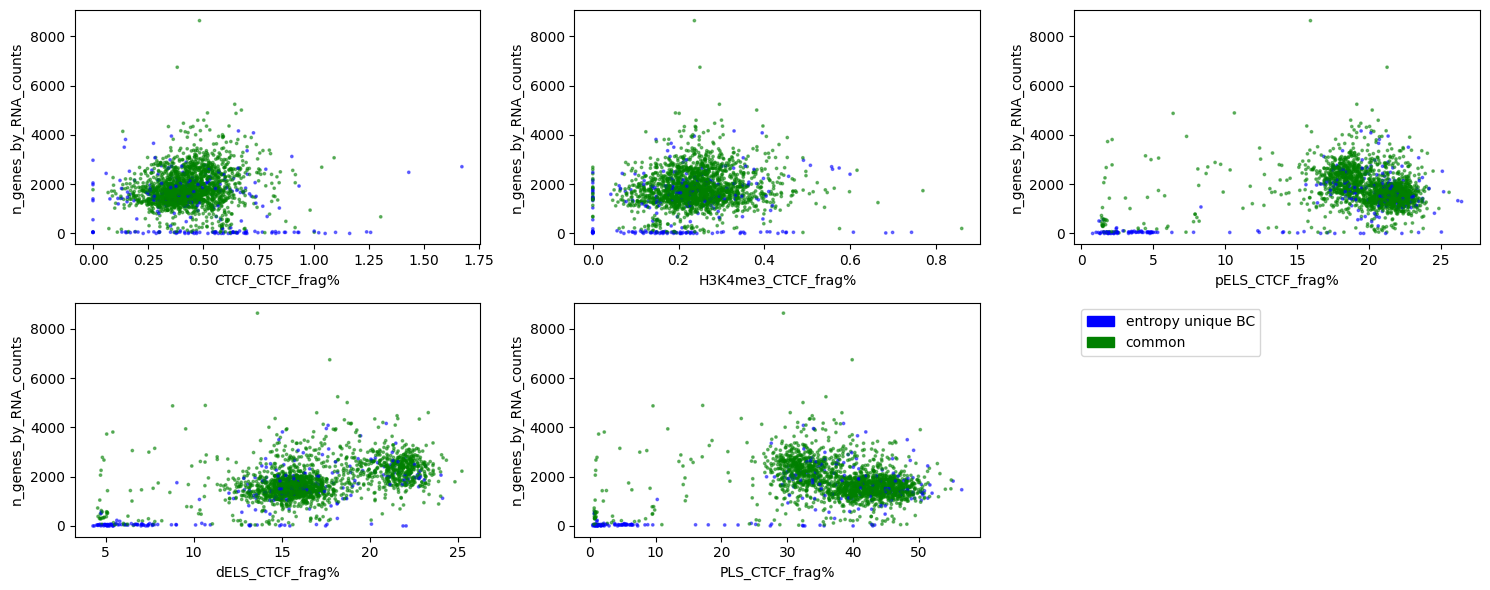

In [33]:
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(15, 6))
ax = ax.flatten()

ctcf_types = ['CTCF_CTCF_frag%', 'H3K4me3_CTCF_frag%', 'pELS_CTCF_frag%', 'dELS_CTCF_frag%', 'PLS_CTCF_frag%']

for i, ctcf in enumerate(ctcf_types):
    ax[i].scatter(h5_rna.obs[ctcf],
           h5_rna.obs['n_genes_by_RNA_counts'] , alpha=0.5, s=3, c=h5_rna.obs['_2set_identified_by_atac_SC'].map({'entropy_only': 'blue', 'both': 'green'}))
    ax[i].set_xlabel(ctcf)
    ax[i].set_ylabel('n_genes_by_RNA_counts')
    
ax[5].legend(handles=[mpatches.Patch(color='blue', label='entropy unique BC'), mpatches.Patch(color='green', label='common')], loc='upper left')
ax[5].axis('off')
plt.tight_layout()


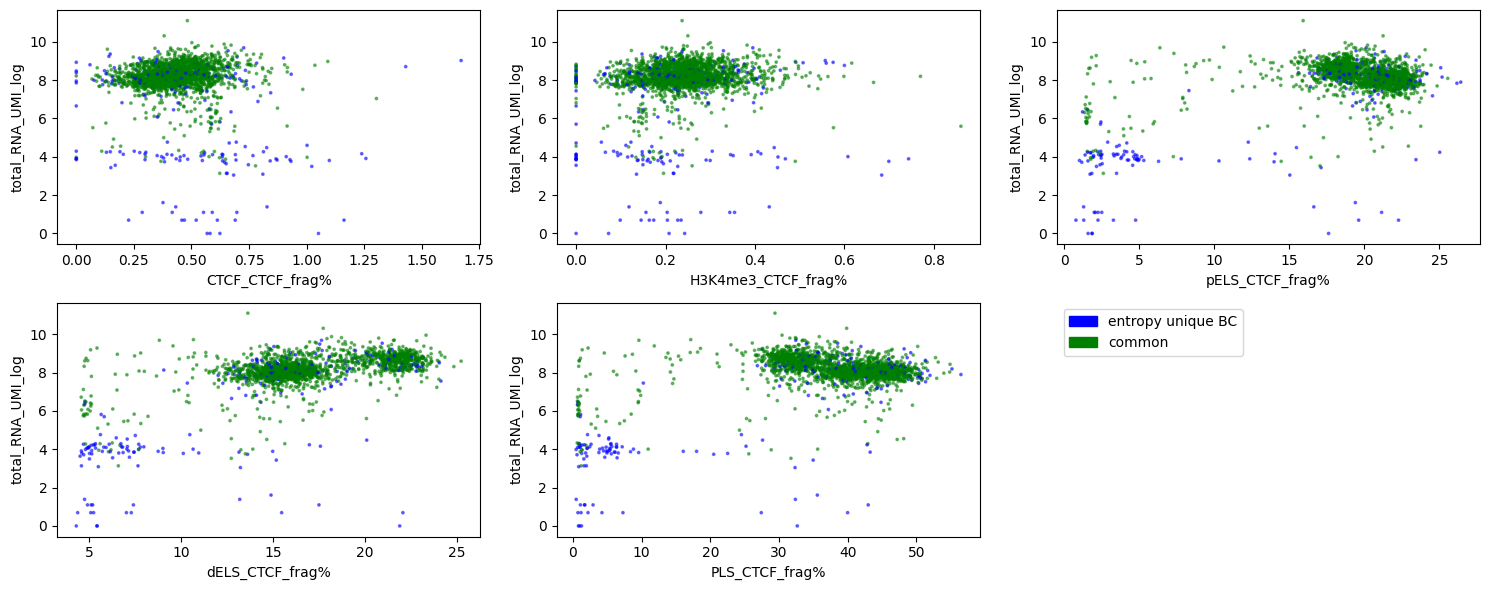

In [34]:
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(15, 6))
ax = ax.flatten()

ctcf_types = ['CTCF_CTCF_frag%', 'H3K4me3_CTCF_frag%', 'pELS_CTCF_frag%', 'dELS_CTCF_frag%', 'PLS_CTCF_frag%']

for i, ctcf in enumerate(ctcf_types):
    ax[i].scatter(h5_rna.obs[ctcf],
           h5_rna.obs['total_RNA_UMI_log'] , alpha=0.5, s=3, c=h5_rna.obs['_2set_identified_by_atac_SC'].map({'entropy_only': 'blue', 'both': 'green'}))
    ax[i].set_xlabel(ctcf)
    ax[i].set_ylabel('total_RNA_UMI_log')
    
ax[5].legend(handles=[mpatches.Patch(color='blue', label='entropy unique BC'), mpatches.Patch(color='green', label='common')], loc='upper left')
ax[5].axis('off')
plt.tight_layout()

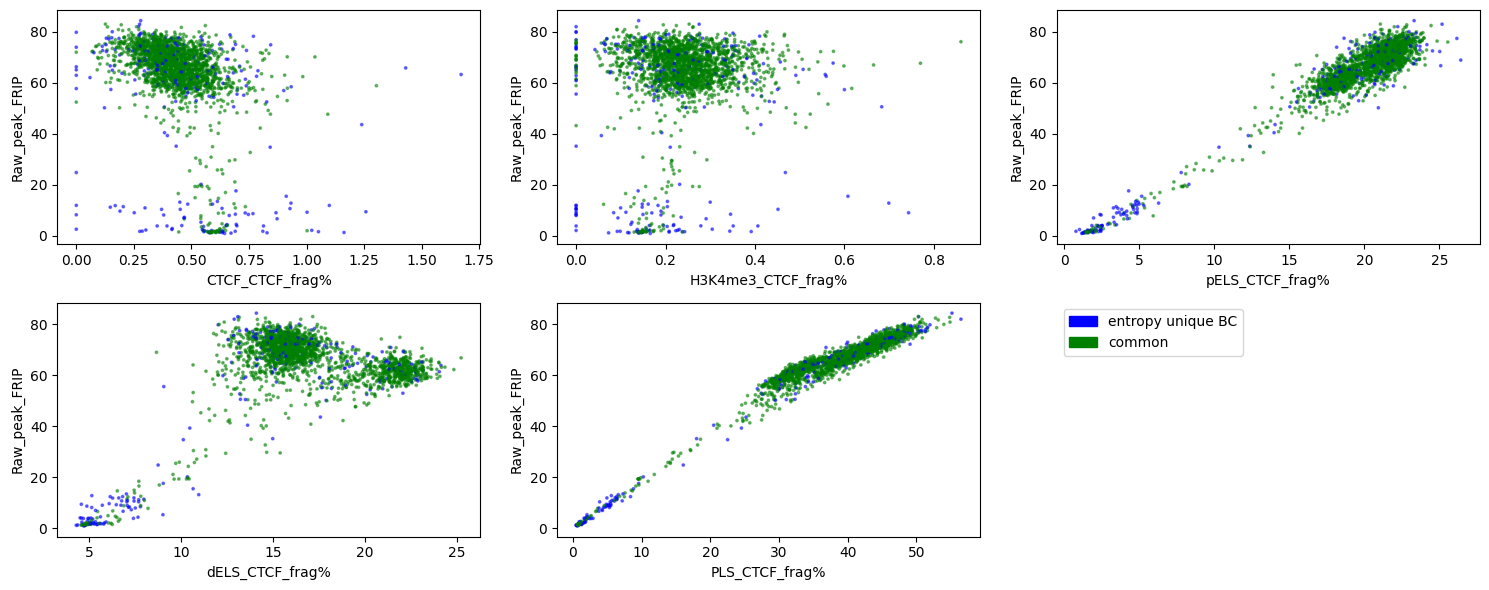

In [35]:
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(15, 6))
ax = ax.flatten()

ctcf_types = ['CTCF_CTCF_frag%', 'H3K4me3_CTCF_frag%', 'pELS_CTCF_frag%', 'dELS_CTCF_frag%', 'PLS_CTCF_frag%']

for i, ctcf in enumerate(ctcf_types):
    ax[i].scatter(h5_rna.obs[ctcf],
           h5_rna.obs['Raw_peak_FRIP'] , alpha=0.5, s=3, c=h5_rna.obs['_2set_identified_by_atac_SC'].map({'entropy_only': 'blue', 'both': 'green'}))
    ax[i].set_xlabel(ctcf)
    ax[i].set_ylabel('Raw_peak_FRIP')
    
ax[5].legend(handles=[mpatches.Patch(color='blue', label='entropy unique BC'), mpatches.Patch(color='green', label='common')], loc='upper left')
ax[5].axis('off')
plt.tight_layout()

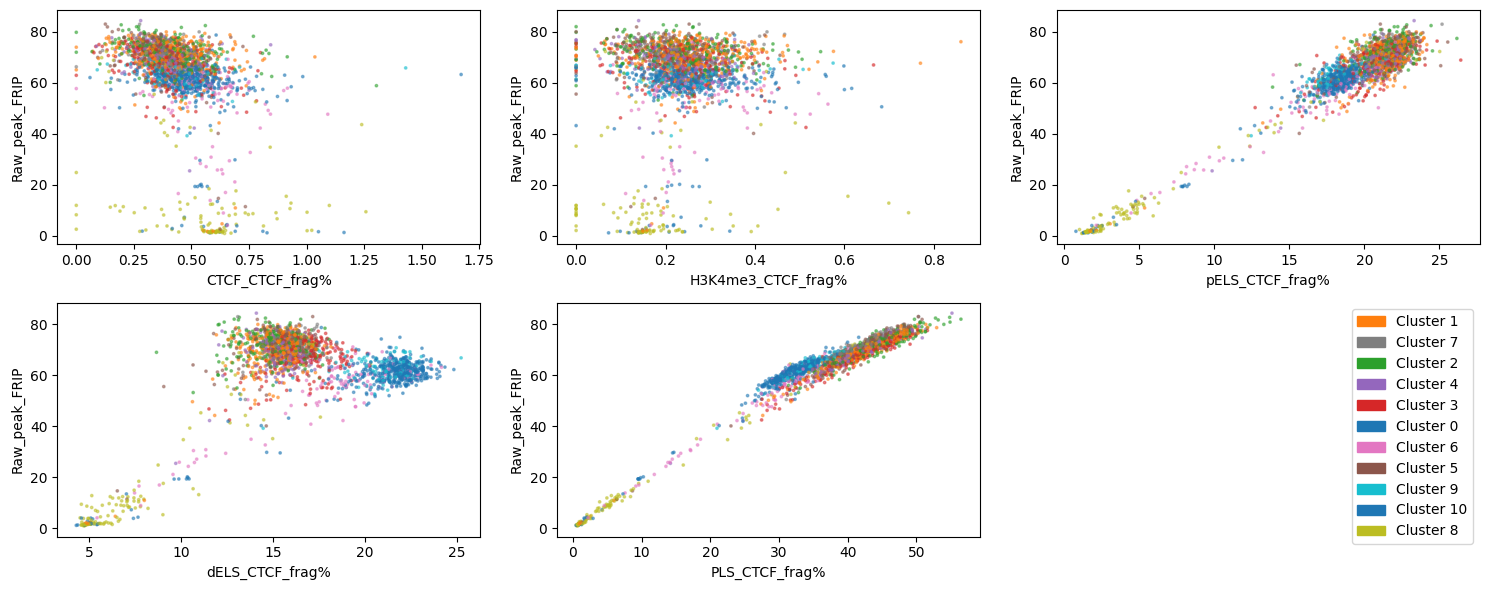

In [36]:
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(15, 6))
ax = ax.flatten()

ctcf_types = ['CTCF_CTCF_frag%', 'H3K4me3_CTCF_frag%', 'pELS_CTCF_frag%', 'dELS_CTCF_frag%', 'PLS_CTCF_frag%']

for i, ctcf in enumerate(ctcf_types):
    ax[i].scatter(h5_rna.obs[ctcf],
           h5_rna.obs['Raw_peak_FRIP'] , alpha=0.5, s=3, c=h5_rna.obs['leiden_RNA_scVI'].map(lambda x: f"C{int(x)}"))
    ax[i].set_xlabel(ctcf)
    ax[i].set_ylabel('Raw_peak_FRIP')
    
ax[5].legend(handles=[mpatches.Patch(color=f"C{int(c)}", label=f"Cluster {c}") for c in h5_rna.obs['leiden_RNA_scVI'].unique()], loc='upper right', bbox_to_anchor=(1, 1))
ax[5].axis('off')
plt.tight_layout()

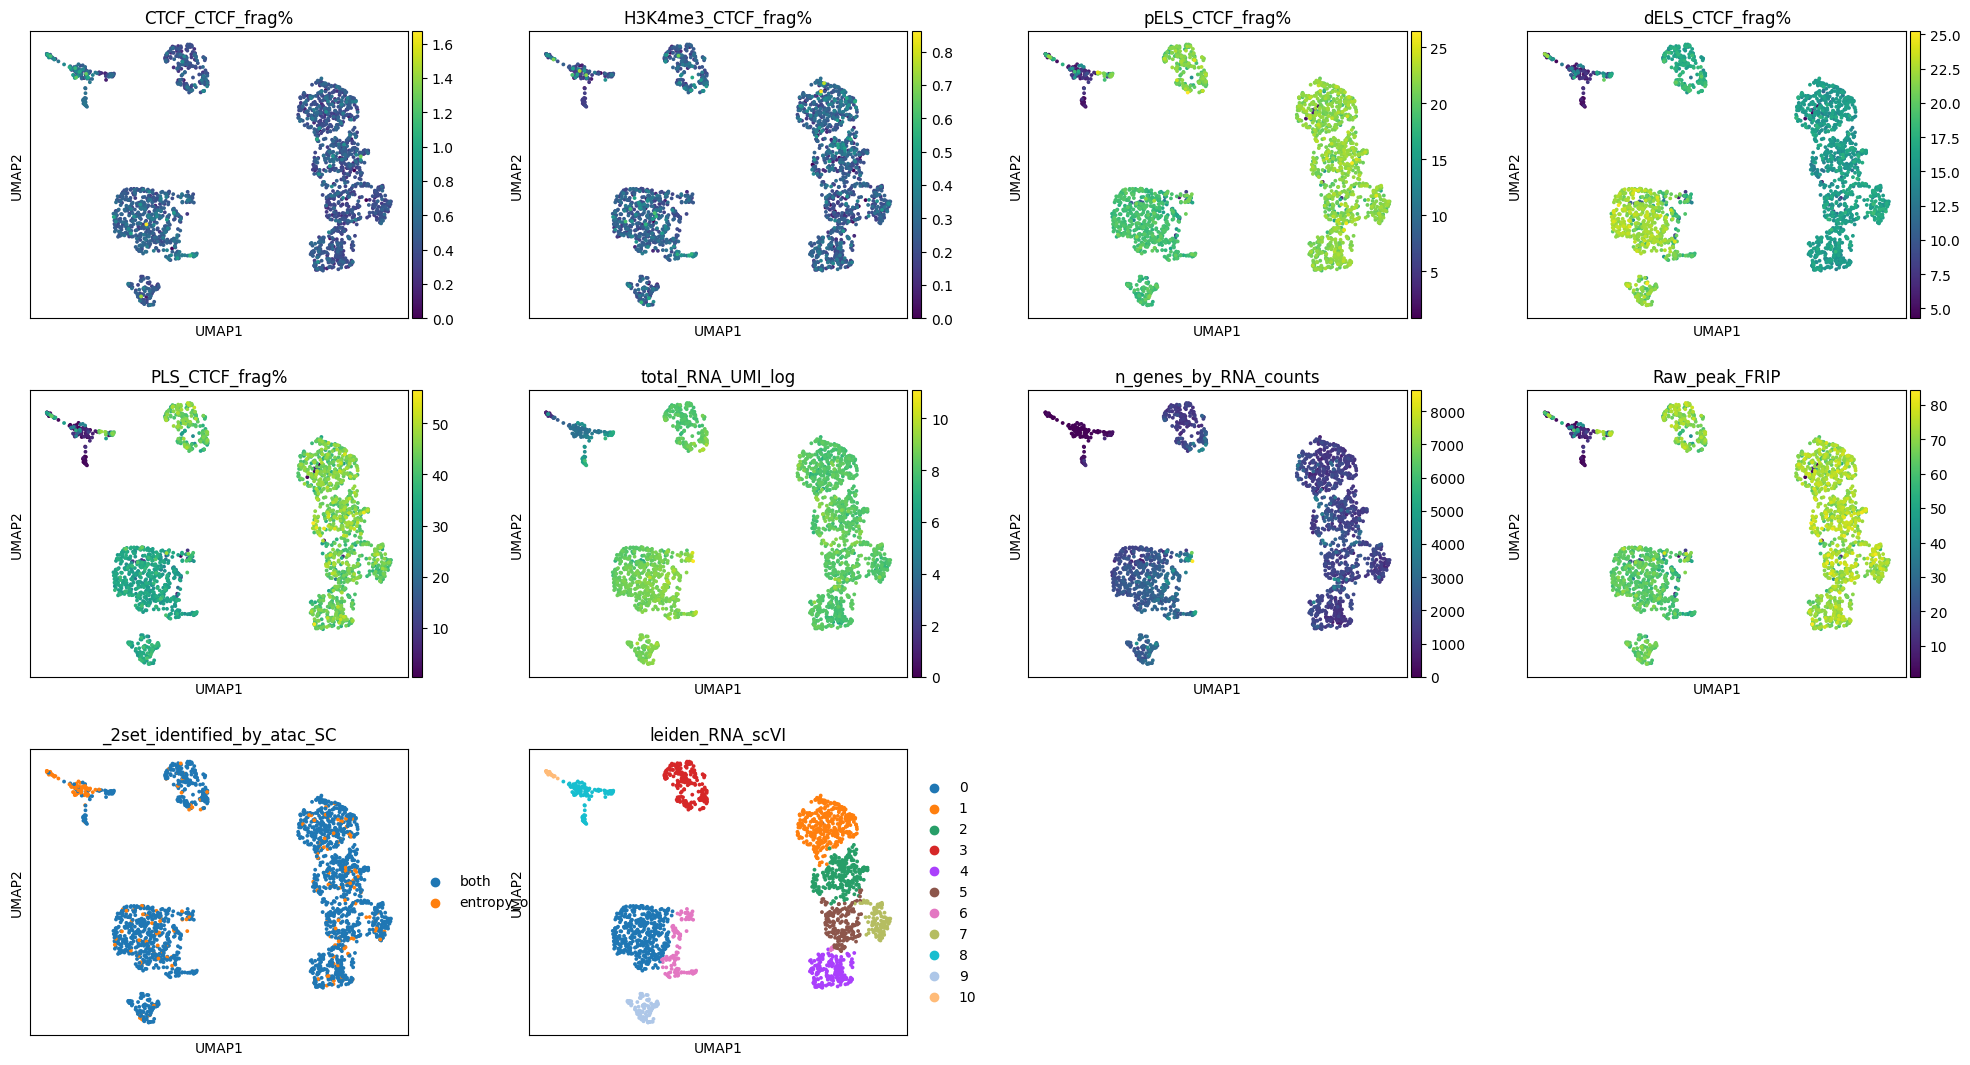

In [37]:
with plt.rc_context({'figure.figsize': (5, 4)}):
    sc.pl.umap(h5_rna, color=ctcf_types + ['total_RNA_UMI_log', 'n_genes_by_RNA_counts', 'Raw_peak_FRIP'] + ['_2set_identified_by_atac_SC', 'leiden_RNA_scVI'], wspace=0.2, size=30, ncols=4)

In [ ]:
RNA_info_dir = os.path.join(entropy_dir, 'RNA_info')
# h5_rna.write_h5ad(os.path.join(RNA_info_dir, 'entropy_filtered_bc_rna_w_CTCFinfo.h5ad'))
# h5_rna.obs.to_csv(os.path.join(RNA_info_dir, 'entropy_filtered_bc_rna_obs_w_CTCFinfo.csv'))


# h5_rna

AnnData object with n_obs × n_vars = 2126 × 21770
    obs: 'barcodes', 'atac_barcodes', 'total_RNA_UMI', 'total_RNA_UMI_log', 'n_genes_by_RNA_counts', 'N_MT_counts', 'MT%', '_scvi_batch', '_scvi_labels', 'leiden_RNA_scVI', 'standard_peak_FRIP', 'entropy_peak_FRIP', 'Entropy', 'Entropy_log', 'clusters_peakvi_highres_entropy', 'clusters_peakvi_entropy', 'reorder_clusters_peakvi_entropy', 'reorder_clusters_peakvi_highres_entropy', 'clusters_peakvi_standard', 'clusters_peakvi_highres_standard', '_2set_identified_by_atac_SC', 'RNA_doublet_score', 'RNA_predicted_doublet', 'rna_pass_CR', 'total_fragments', 'H3K4me3_CTCF_frag_count', 'CTCF_CTCF_frag_count', 'H3K4me3_CTCF_frag%', 'CTCF_CTCF_frag%', 'pELS_CTCF_frag_count', 'dELS_CTCF_frag_count', 'PLS_CTCF_frag_count', 'pELS_CTCF_frag%', 'dELS_CTCF_frag%', 'PLS_CTCF_frag%'
    var: 'feature_id', 'name', 'feature_type', 'chrom', 'start', 'end', 'gene_name', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_no

In [ ]:
rna_cell_type_subdir = os.path.join(RNA_info_dir,  '_rna_cell_types')
# clusters = [8, 10]
# for cluster in clusters:
#     write_file = 'RNAcluster_' + str(cluster) + '_df.csv' 
#     write_file_path = os.path.join(rna_cell_type_subdir, write_file)
#     h5_rna.obs.loc[h5_rna.obs['leiden_RNA_scVI'] == str(cluster), :].to_csv(write_file_path, index=False)

## Plot to see consistency between atac space and rna space 

In [ ]:
if 'clusters_peakvi_entropy' in h5_rna.obs.columns:
    h5_rna.obs.drop('clusters_peakvi_entropy', axis=1, inplace=True)
if 'reorder_clusters_peakvi_entropy' in h5_rna.obs.columns:
    h5_rna.obs.drop('reorder_clusters_peakvi_entropy', axis=1, inplace=True)

if 'clusters_peakvi_standard' in h5_rna.obs.columns:
    h5_rna.obs.drop('clusters_peakvi_standard', axis=1, inplace=True)


h5_rna.obs = h5_rna.obs.merge(entropy_peak.obs[['clusters_peakvi_entropy', 'reorder_clusters_peakvi_entropy']], left_on='atac_barcodes', right_index=True, how='left')
h5_rna.obs = h5_rna.obs.merge(peak.obs[['clusters_peakvi_standard']], left_on='atac_barcodes', right_index=True, how='left')

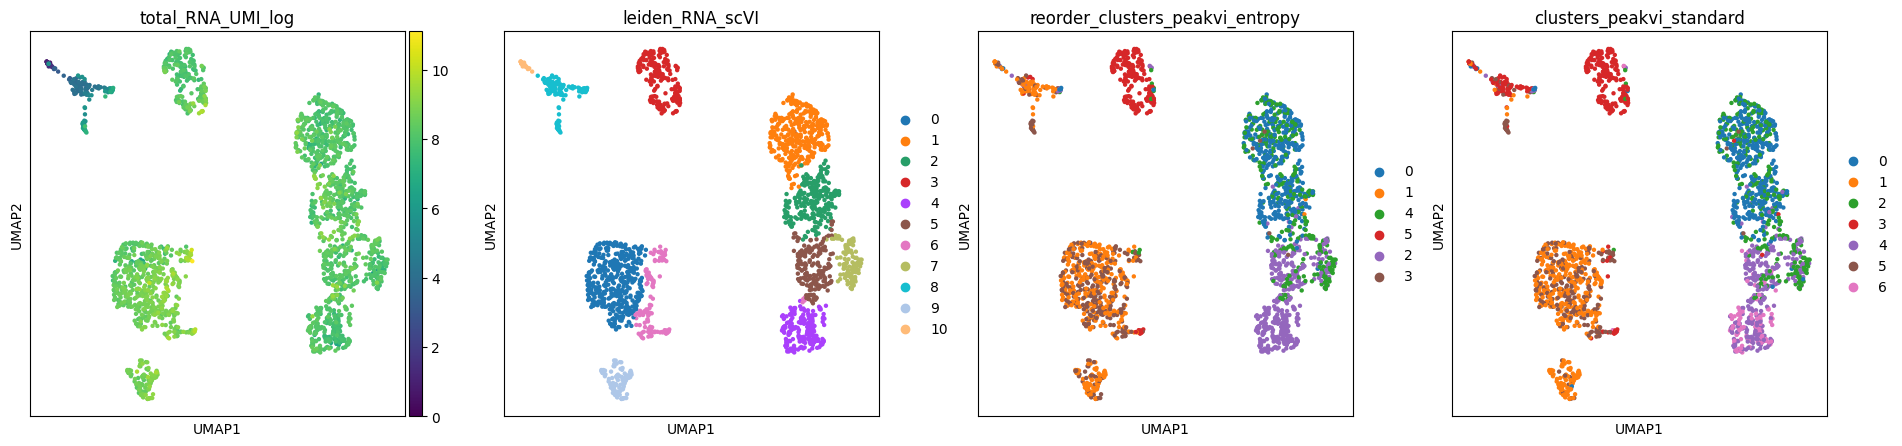

In [59]:
with plt.rc_context({'figure.figsize': (5, 5)}):
    sc.pl.umap(h5_rna, color=['total_RNA_UMI_log', 'leiden_RNA_scVI', 'reorder_clusters_peakvi_entropy', 'clusters_peakvi_standard'], wspace=0.15, ncols=4, size=40)

### On finer resolution

In [61]:
relate_labels2 = peak_df.join(entropy_peak_df['clusters_peakvi_highres_entropy']).groupby(['clusters_peakvi_highres_standard', 'clusters_peakvi_highres_entropy']).size().unstack(fill_value=0)

relate_labels2 = relate_labels2.to_numpy()
ordered_col, remained_col = order_m(relate_labels2)

# # Now manually map the best matching clusters
entropy_peak.obs['reorder_clusters_peakvi_highres_entropy'] = entropy_peak.obs['clusters_peakvi_highres_entropy'].cat.reorder_categories([str(i) for i in ordered_col+remained_col], ordered=False)

/tmp/ipykernel_496479/3685768261.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  relate_labels2 = peak_df.join(entropy_peak_df['clusters_peakvi_highres_entropy']).groupby(['clusters_peakvi_highres_standard', 'clusters_peakvi_highres_entropy']).size().unstack(fill_value=0)


In [62]:
if 'reorder_clusters_peakvi_entropy' in h5_rna.obs.columns:
    h5_rna.obs.drop('reorder_clusters_peakvi_entropy', axis=1, inplace=True)
if 'reorder_clusters_peakvi_highres_entropy' in h5_rna.obs.columns:
    h5_rna.obs.drop('reorder_clusters_peakvi_highres_entropy', axis=1, inplace=True)

if 'clusters_peakvi_standard' in h5_rna.obs.columns:
    h5_rna.obs.drop('clusters_peakvi_standard', axis=1, inplace=True)
if 'clusters_peakvi_highres_standard' in h5_rna.obs.columns:
    h5_rna.obs.drop('clusters_peakvi_highres_standard', axis=1, inplace=True)

    

h5_rna.obs = h5_rna.obs.merge(entropy_peak.obs[['reorder_clusters_peakvi_entropy', 'reorder_clusters_peakvi_highres_entropy']], left_on='atac_barcodes', right_index=True, how='left')

h5_rna.obs = h5_rna.obs.merge(peak.obs[['clusters_peakvi_standard', 'clusters_peakvi_highres_standard']], left_on='atac_barcodes', right_index=True, how='left')



#### Doublet score

In [90]:
import doubletdetection
clf = doubletdetection.BoostClassifier(
    n_iters=10, 
    clustering_algorithm="louvain", 
    standard_scaling=True,
    pseudocount=0.1,
    n_jobs=-1,
)
doublets = clf.fit(h5_rna.layers['counts'].toarray()).predict(p_thresh=1e-16, voter_thresh=0.5)
doublet_score = clf.doublet_score()

h5_rna.obs["RNA_doublet_score"] = doublet_score
h5_rna.obs["RNA_predicted_doublet"] = ['doublets' if x else 'singlets' for x in doublets]

100%|██████████| 10/10 [00:08<00:00,  1.16it/s]


In [93]:
%matplotlib inline

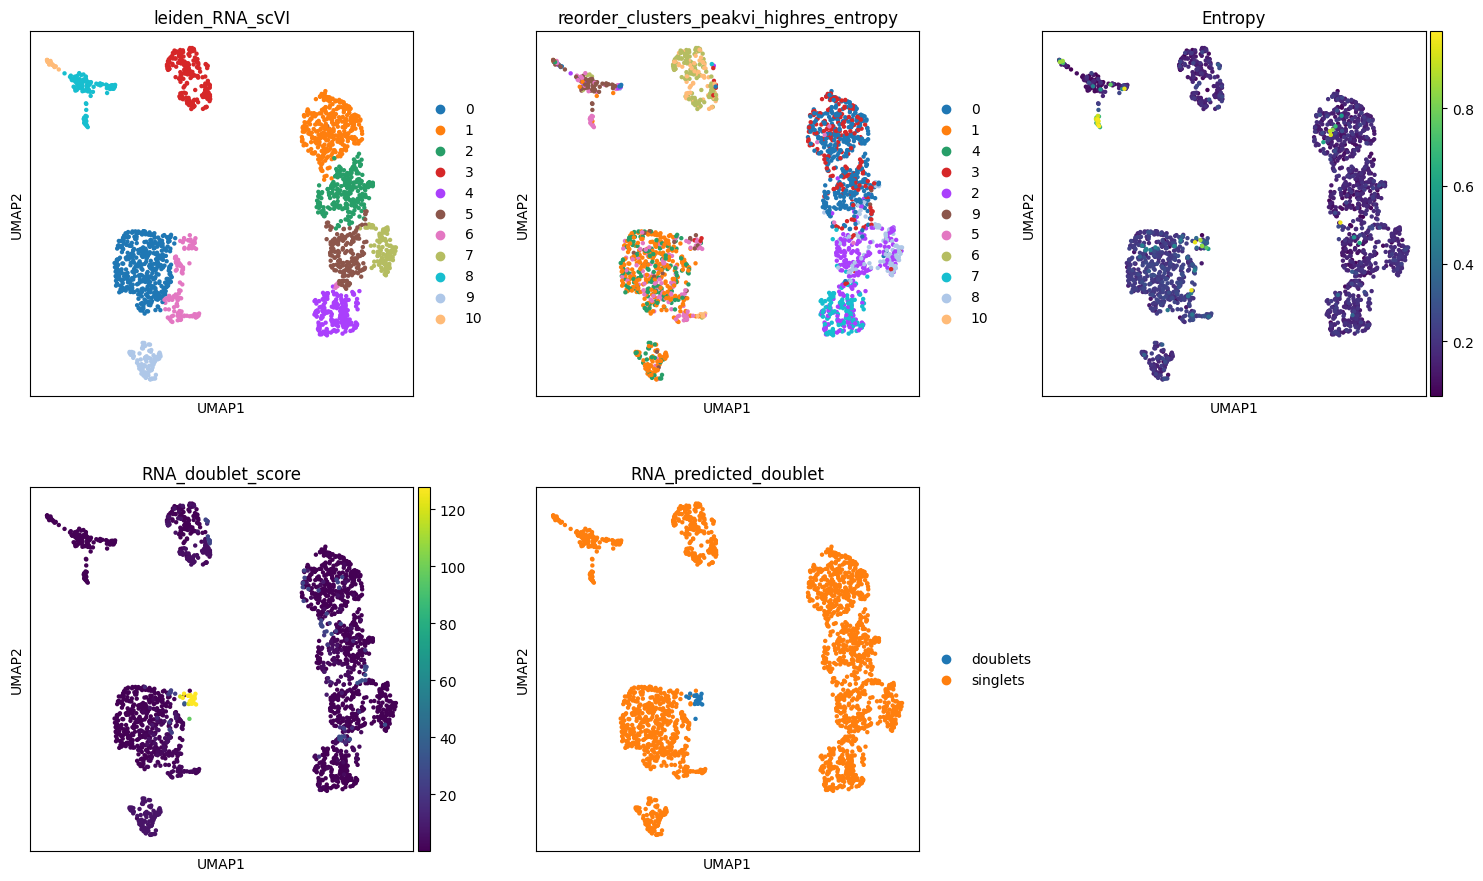

In [95]:
with plt.rc_context({'figure.figsize': (5, 5)}):
    sc.pl.umap(h5_rna, color=["leiden_RNA_scVI", "reorder_clusters_peakvi_highres_entropy", "Entropy", "RNA_doublet_score", "RNA_predicted_doublet"], size=40, ncols=3, wspace=0.2)
    

Text(0, 0.5, 'Entropy Score')

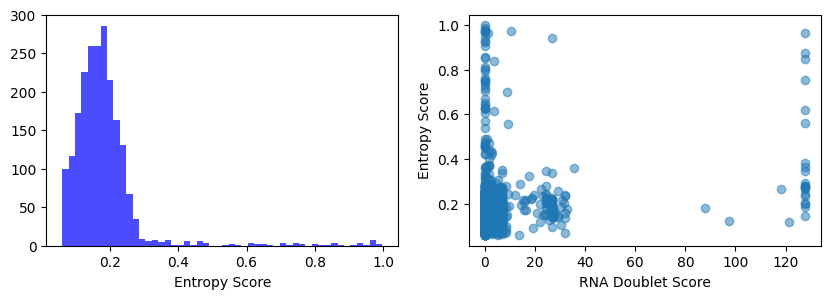

In [56]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
_ = ax[0].hist(h5_rna.obs['Entropy'], bins=50, color='blue', alpha=0.7)
ax[0].set_xlabel('Entropy Score')

ax[1].scatter(h5_rna.obs['RNA_doublet_score'], h5_rna.obs['Entropy'],  alpha=0.5)
ax[1].set_xlabel('RNA Doublet Score')
ax[1].set_ylabel('Entropy Score')

Text(0.5, 0, 'Entropy value (log)')

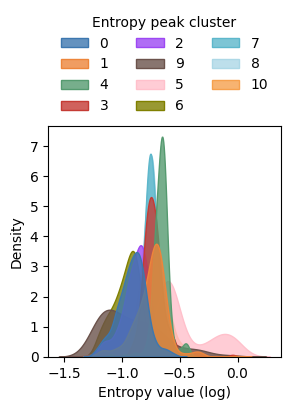

In [57]:
color_order = {'0': '#3d77af', '1': '#ed853b', '2': '#559a6f', '3': '#c53b34', '4': '#9d48f3',
             '5': '#6b524b', '6': 'pink', '7': 'olive', '8': '#5db7cb', '9': 'lightblue', 
                '10': '#f6a04d', '11': '#8fd18b', '12': 'lightcoral'}#, '13': 'lime'}
entropy_peak_cluster_order = h5_rna.obs['reorder_clusters_peakvi_highres_entropy'].cat.categories.tolist()
color_map = {k: color_order[str(i)] for i, k in enumerate(entropy_peak_cluster_order)}

fig, ax = plt.subplots(figsize=(3, 3))
kde = sns.kdeplot(data=h5_rna.obs, x='Entropy_log', hue='reorder_clusters_peakvi_highres_entropy', 
                  palette=color_map,
                  fill=True, 
                  ax=ax, alpha=0.8, common_norm=False)
sns.move_legend(
    kde, "lower center",
    bbox_to_anchor=(.5, 1), ncol=3, title='Entropy peak cluster', frameon=False
)

ax.set_xlabel('Entropy value (log)')


In [58]:
h5_rna.obs['reorder_clusters_peakvi_highres_entropy'].cat.categories

Index(['0', '1', '4', '3', '2', '9', '5', '6', '7', '8', '10'], dtype='object')

# On ATAC space

## Umap on ATAC space

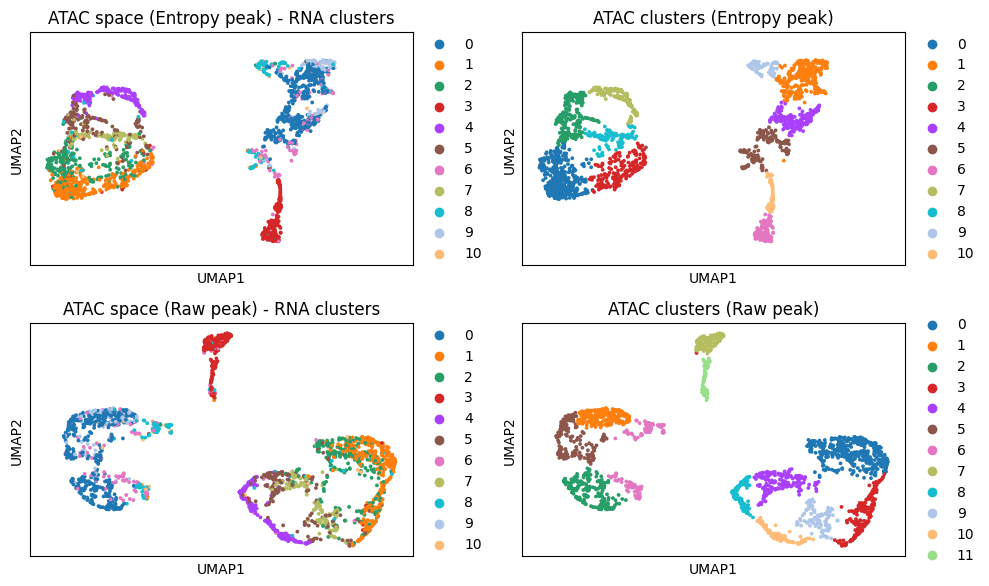

In [48]:
if 'leiden_RNA_scVI' in entropy_peak.obs.columns:
    entropy_peak.obs.drop('leiden_RNA_scVI', axis=1, inplace=True)
if 'leiden_RNA_scVI' in peak.obs.columns:
    peak.obs.drop('leiden_RNA_scVI', axis=1, inplace=True)
    
entropy_peak.obs = entropy_peak.obs.merge(h5_rna.obs[['leiden_RNA_scVI']], left_on='rna_barcodes', right_index=True, how='left')
peak.obs = peak.obs.merge(h5_rna.obs[['leiden_RNA_scVI']], left_on='rna_barcodes', right_index=True, how='left')



fig, ax = plt.subplots(2, 2, figsize=(10,6), sharex=True, sharey=True)
ax = ax.flatten()
sc.pl.umap(entropy_peak, color=['leiden_RNA_scVI'], title='ATAC space (Entropy peak) - RNA clusters', size=30, ax=ax[0], show=False)
sc.pl.umap(entropy_peak, color=['clusters_peakvi_highres_entropy'], title='ATAC clusters (Entropy peak)', size=30, ax=ax[1], show=False)


sc.pl.umap(peak, color=['leiden_RNA_scVI'], title='ATAC space (Raw peak) - RNA clusters', size=30, ax=ax[2], show=False)
sc.pl.umap(peak, color=['clusters_peakvi_highres_standard'], title='ATAC clusters (Raw peak)', size=30, ax=ax[3], show=False)

fig.tight_layout()

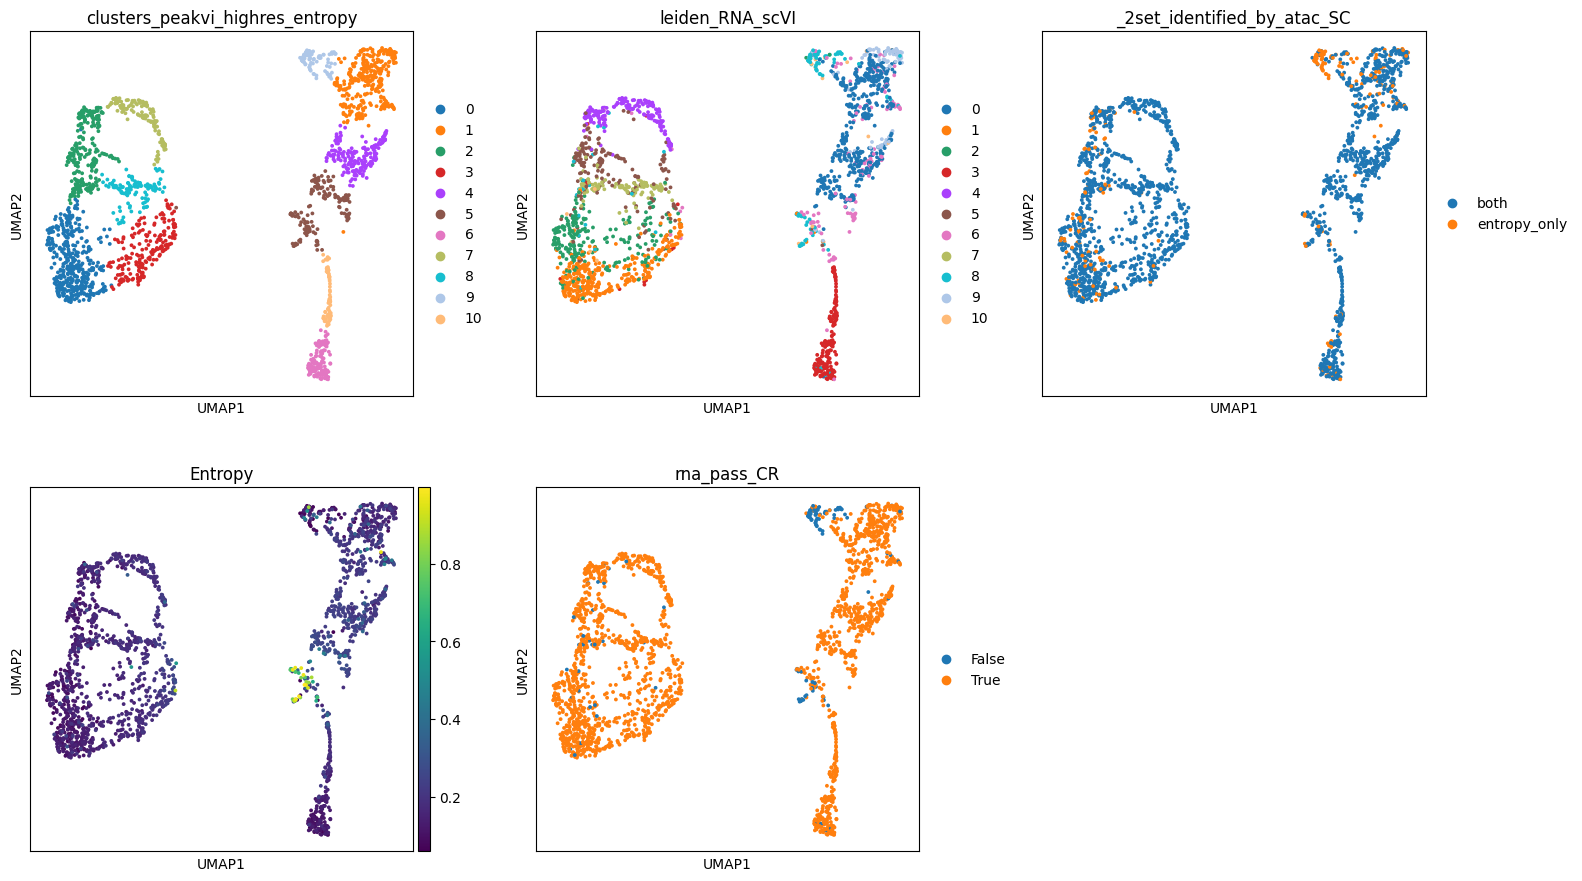

In [53]:
with plt.rc_context({'figure.figsize': (5, 5)}):
    sc.pl.umap(entropy_peak, color=['clusters_peakvi_highres_entropy', 'leiden_RNA_scVI', '_2set_identified_by_atac_SC'] + 
               ['Entropy', 'rna_pass_CR'], wspace=0.2, ncols=3, size=30)

In [61]:
sc.tl.leiden(entropy_peak, key_added=f"leiden_entropy_res{atac_resolution + 0.2}", resolution=atac_resolution + 0.2)

sc.tl.leiden(peak, key_added=f"leiden_standard_res{atac_resolution + 0.2}", resolution=atac_resolution + 0.2)

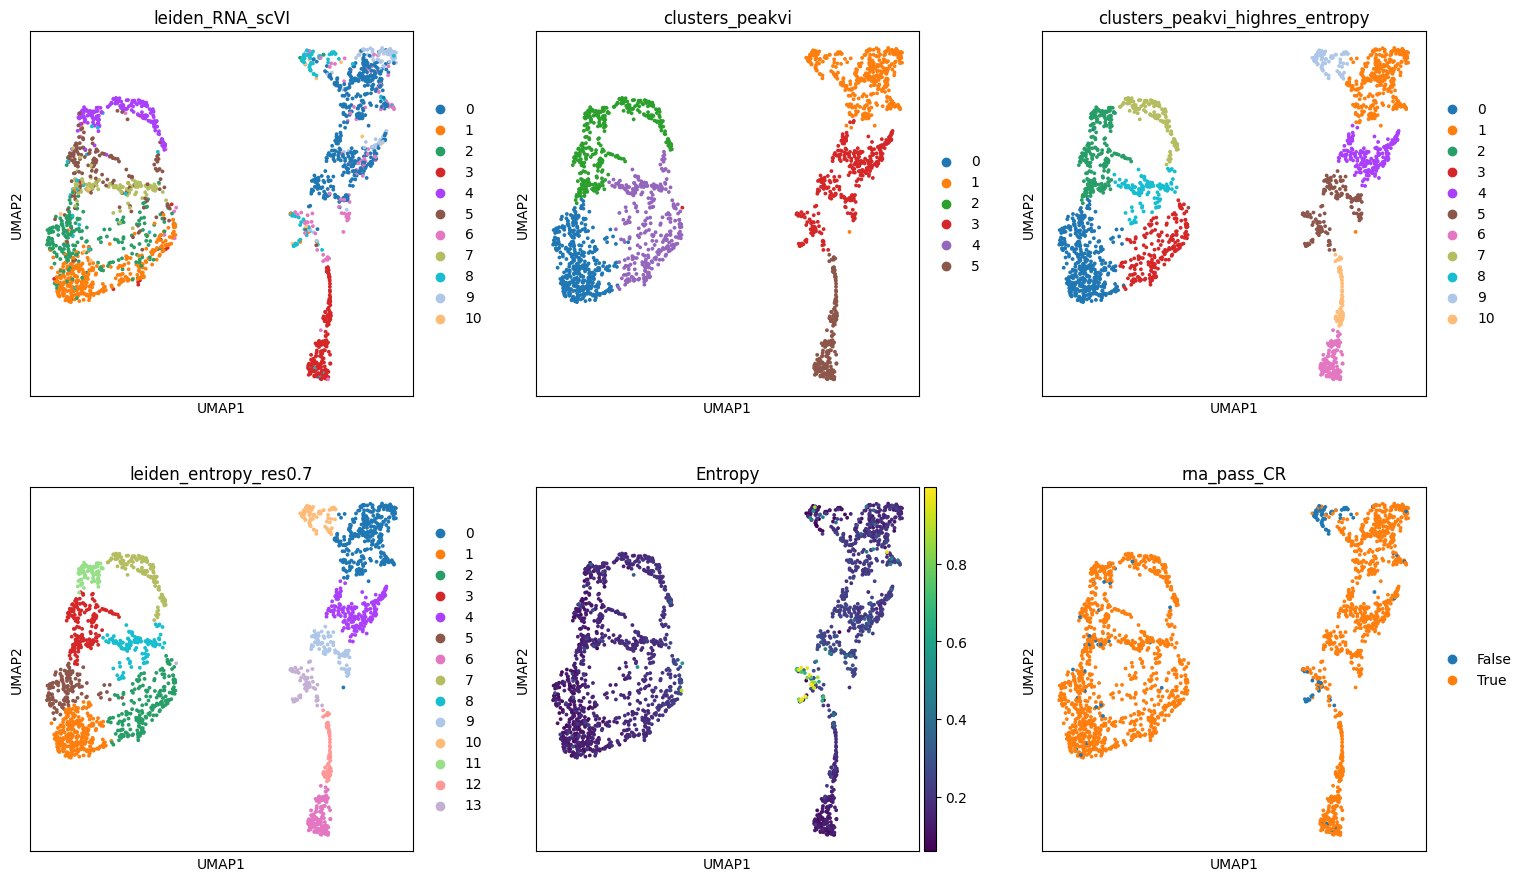

In [64]:
with plt.rc_context({'figure.figsize': (5, 5)}):
    sc.pl.umap(entropy_peak, color=['leiden_RNA_scVI', 'clusters_peakvi',  'clusters_peakvi_highres_entropy', f'leiden_entropy_res{atac_resolution + 0.2}'] +
               ['Entropy', 'rna_pass_CR'] , wspace=0.2, ncols=3, size=30)

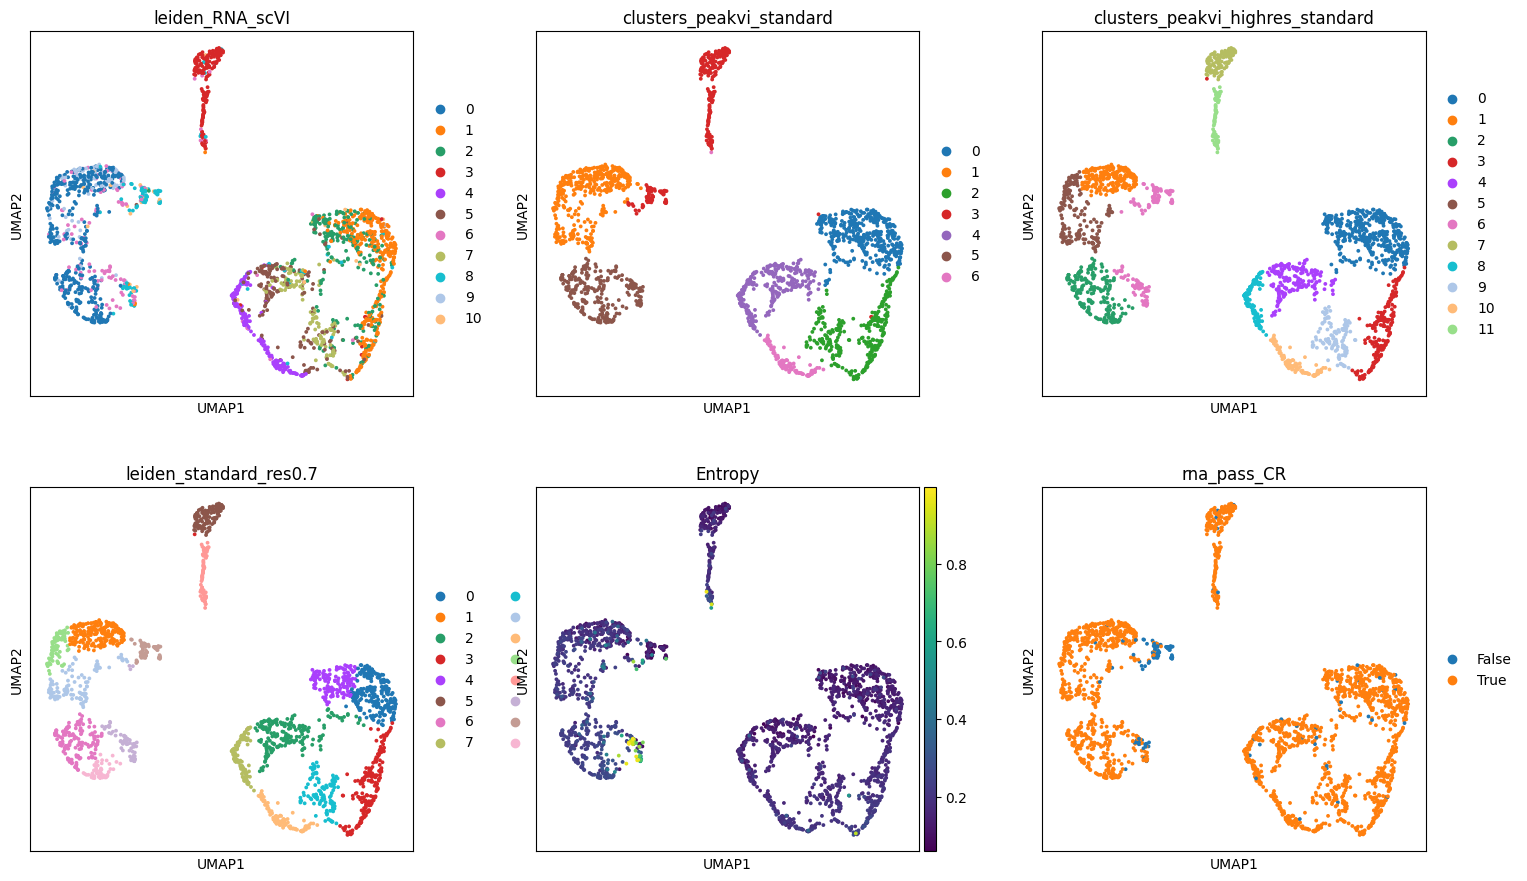

In [67]:
with plt.rc_context({'figure.figsize': (5, 5)}):
    sc.pl.umap(peak, color=['leiden_RNA_scVI', 'clusters_peakvi_standard',  'clusters_peakvi_highres_standard', f'leiden_standard_res{atac_resolution + 0.2}'] +
               ['Entropy', 'rna_pass_CR'] , wspace=0.2, ncols=3, size=30)